In [17]:
import cv2
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [18]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min

def balanced_k_means(data, k, cluster_size, max_iter=100, num_initializations=10):
    """
    Perform Balanced K-means clustering using scikit-learn.
    
    Args:
        data (ndarray): Data points (n_samples, n_features).
        k (int): Number of clusters.
        cluster_size (int): Desired size of each cluster.
        max_iter (int): Maximum number of iterations for k-means.
        num_initializations (int): Number of initializations to try.
    
    Returns:
        best_labels (ndarray): Cluster labels for each data point.
        best_centroids (ndarray): Final centroids with the lowest inertia.
        best_inertia (float): Minimum inertia achieved.
    """
    n_samples, n_features = data.shape
    assert n_samples == k * cluster_size, "Number of samples must be divisible by cluster size."

    best_inertia = np.inf
    best_labels = None
    best_centroids = None

    for init in range(num_initializations):
        # Use scikit-learn's KMeans to cluster data
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            max_iter=max_iter,
            n_init=1,
            random_state=init
        )
        kmeans.fit(data)

        # Get initial cluster labels and centroids
        initial_labels = kmeans.labels_
        centroids = kmeans.cluster_centers_

        # Enforce balance by reassigning points to clusters
        distances, _ = pairwise_distances_argmin_min(data, centroids)
        sorted_indices = np.argsort(distances)
        clusters = [[] for _ in range(k)]

        for idx in sorted_indices:
            # Assign the point to the least populated cluster
            for cluster_id in range(k):
                if len(clusters[cluster_id]) < cluster_size:
                    clusters[cluster_id].append(idx)
                    break

        # Update labels to reflect balanced assignment
        balanced_labels = np.zeros(n_samples, dtype=int)
        for cluster_id, cluster_indices in enumerate(clusters):
            for idx in cluster_indices:
                balanced_labels[idx] = cluster_id

        # Compute inertia for the balanced clustering
        inertia = sum(
            np.sum((data[clusters[cluster_id]] - centroids[cluster_id])**2)
            for cluster_id in range(k)
        )

        # Update best solution if this is the best inertia so far
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = balanced_labels
            best_centroids = centroids

    return best_labels, best_centroids, best_inertia

In [19]:

# Function to draw a smaller, centered 3x3 grid on an image
def draw_centered_grid(image, grid_size=100):
    h, w, _ = image.shape
    center_x, center_y = w // 2, h // 2

    # Calculate the grid boundaries
    half_size = grid_size // 2
    top_left_x, top_left_y = center_x - half_size, center_y - half_size
    bottom_right_x, bottom_right_y = center_x + half_size, center_y + half_size

    # Draw the grid
    cell_size = grid_size // 3
    for i in range(4):
        y = top_left_y + i * cell_size
        x = top_left_x + i * cell_size
        cv2.line(image, (top_left_x, y), (bottom_right_x, y), (255, 255, 255), 2)
        cv2.line(image, (x, top_left_y), (x, bottom_right_y), (255, 255, 255), 2)

    return image, (top_left_x, top_left_y, cell_size)


# Function to detect the dominant color in a square
def detect_dominant_color(square, neighborhood_fraction=0.25, blur_ksize=5):
    h, w, _ = square.shape
    center_x, center_y = w // 2, h // 2

    # Define the neighborhood size
    offset_x = int(w * neighborhood_fraction // 2)
    offset_y = int(h * neighborhood_fraction // 2)

    # Extract the neighborhood region
    neighborhood = square[center_y - offset_x:center_y + offset_x, center_x - offset_y:center_x + offset_y]

    # Apply Gaussian blur to the neighborhood
    blurred = cv2.GaussianBlur(neighborhood, (blur_ksize, blur_ksize), 0)

    # Calculate the average color in the blurred neighborhood
    avg_color = blurred.mean(axis=0).mean(axis=0)
    return tuple(map(int, avg_color))  # Convert to (B, G, R)


# Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

captured_faces = []  # List to store captured face images
color_data = []  # List to store color data for each face
capture_limit = 6  # Number of faces to capture

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    # Draw the smaller, centered 3x3 grid on the frame
    grid_frame, grid_info = draw_centered_grid(frame.copy(), grid_size=200)

    # Display the live webcam feed with the smaller grid overlay
    cv2.imshow('Align Your Cube and Press Space', grid_frame)

    key = cv2.waitKey(1)

    if key == ord('q') or key == 27:  # Quit on 'q' or 'Esc'
        break
    elif key == ord(' '):  # Capture on spacebar
        if len(captured_faces) < capture_limit:
            captured_faces.append(frame.copy())
            print(f"Captured face {len(captured_faces)}")

            # Analyze grid colors
            top_left_x, top_left_y, cell_size = grid_info
            colors = []
            for i in range(3):
                for j in range(3):
                    x1 = top_left_x + j * cell_size
                    y1 = top_left_y + i * cell_size
                    x2 = x1 + cell_size
                    y2 = y1 + cell_size
                    square = frame[y1:y2, x1:x2]
                    dominant_color = detect_dominant_color(square)
                    colors.append(dominant_color)
            color_data.append(colors)
        else:
            print("All 6 faces have already been captured!")

    # Check if all faces are captured
    if len(captured_faces) == capture_limit:
        break

cap.release()
cv2.destroyAllWindows()

print(color_data)
# Display the final color palette
if len(color_data) == capture_limit:
    # Create a blank canvas for the color palette
    palette_height = 300
    palette_width = 600
    palette = np.zeros((palette_height, palette_width, 3), dtype=np.uint8)

    face_width = palette_width // 6  # Width of each face in the palette
    cell_size = face_width // 3     # Size of each cell within a face

    for face_idx, face_colors in enumerate(color_data):
        for i in range(3):
            for j in range(3):
                color = face_colors[i * 3 + j]
                top_left_x = face_idx * face_width + j * cell_size
                top_left_y = i * cell_size
                bottom_right_x = top_left_x + cell_size
                bottom_right_y = top_left_y + cell_size
                cv2.rectangle(
                    palette,
                    (top_left_x, top_left_y),
                    (bottom_right_x, bottom_right_y),
                    color,  # Convert BGR to RGB for OpenCV
                    -1  # Filled rectangle
                )

    # Show the color palette
    cv2.imshow('Cube Color Palette', palette)

    # Wait for user input to close the window
    print("Press any key in the 'Cube Color Palette' window to close.")
    while True:
        if cv2.waitKey(1) & 0xFF in {ord('q'), 27}:  # Quit on 'q' or 'Esc'
            break

    # Destroy the palette window
    cv2.destroyAllWindows()

Captured face 1
Captured face 2
Captured face 3
Captured face 4
Captured face 5
Captured face 6
[[(43, 219, 220), (187, 212, 214), (38, 217, 214), (191, 212, 224), (188, 213, 223), (30, 220, 207), (196, 214, 226), (194, 214, 228), (47, 103, 254)], [(53, 104, 252), (68, 44, 241), (66, 207, 107), (81, 62, 239), (50, 102, 253), (70, 49, 234), (81, 59, 244), (75, 223, 112), (73, 51, 240)], [(58, 109, 253), (76, 215, 109), (188, 208, 216), (83, 223, 118), (74, 221, 108), (74, 219, 110), (84, 59, 248), (87, 65, 246), (76, 225, 114)], [(50, 104, 249), (202, 181, 86), (197, 177, 77), (60, 108, 253), (79, 60, 236), (55, 108, 252), (50, 226, 224), (57, 105, 254), (209, 188, 84)], [(69, 46, 238), (45, 93, 254), (40, 217, 211), (212, 191, 78), (215, 194, 78), (216, 191, 84), (218, 196, 79), (224, 201, 80), (80, 226, 116)], [(74, 215, 112), (39, 226, 208), (186, 207, 222), (49, 229, 226), (36, 231, 224), (197, 217, 221), (204, 225, 230), (53, 235, 234), (214, 195, 83)]]
Press any key in the 'Cube C

In [20]:
# Example data in BGR format
lab_data_bgr = np.array(color_data)

# Flatten the data to a 2D array of shape (n_samples, 3)
lab_data_bgr_flat = lab_data_bgr.reshape(-1, 3).astype(np.uint8)

# Convert from BGR to LAB using OpenCV
# Reshape the data into a proper image format for color conversion
lab_data_bgr_image = lab_data_bgr_flat.reshape(lab_data_bgr.shape[0], lab_data_bgr.shape[1], 3)  # reshape to (height, width, 3)

lab_data_lab = cv2.cvtColor(lab_data_bgr_image, cv2.COLOR_BGR2LAB)

# Now `lab_data_lab` contains the data in LAB color space
print(lab_data_lab)

k = 6
cluster_size = 9


# Flatten `lab_data` into a 2D array
lab_data_flat = np.array(lab_data_lab).reshape(-1, 3)

# Perform Balanced K-means
labels, centroids, inertia = balanced_k_means(lab_data_flat, k, cluster_size, 100, 1)

# Print results
print("Cluster Labels:", labels)
print("Centroids in LAB:", centroids)
print("Inertia:", inertia)

[[[217 110 206]
  [216 124 141]
  [214 108 206]
  [218 129 140]
  [218 127 142]
  [215 104 208]
  [220 129 138]
  [220 130 140]
  [159 183 186]]

 [[159 182 183]
  [135 200 165]
  [191  74 187]
  [139 195 159]
  [159 183 185]
  [133 197 162]
  [140 198 160]
  [204  70 188]
  [136 198 162]]

 [[162 180 182]
  [198  73 185]
  [213 127 139]
  [205  73 186]
  [202  70 188]
  [201  71 187]
  [142 199 159]
  [143 197 158]
  [206  70 189]]

 [[158 181 184]
  [176 106 109]
  [172 105 109]
  [162 181 181]
  [137 195 159]
  [161 180 183]
  [223 108 206]
  [161 182 182]
  [182 104 108]]

 [[134 199 164]
  [155 187 185]
  [214 107 205]
  [184 102 108]
  [186 102 108]
  [185 105 106]
  [188 102 107]
  [192 101 107]
  [207  71 188]]

 [[198  73 186]
  [219 101 207]
  [214 130 140]
  [225 108 207]
  [226 106 211]
  [221 126 138]
  [228 126 139]
  [231 108 208]
  [187 102 109]]]
Cluster Labels: [2 3 2 3 3 2 3 3 1 1 5 4 5 1 5 5 4 5 1 4 3 4 4 4 5 5 4 1 0 0 1 5 1 2 1 0 5
 1 2 0 0 0 0 0 4 4 2 3 2 2 3 3 2 

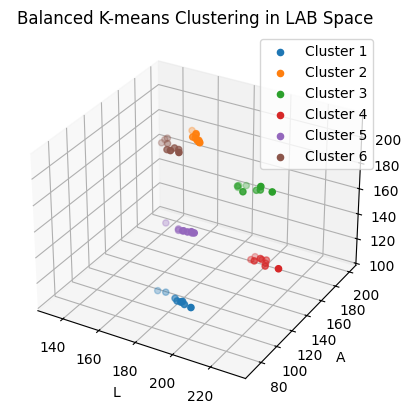

In [21]:
# Convert centroids back to BGR for visualization
bgr_centroids = np.array([cv2.cvtColor(np.uint8([[lab]]), cv2.COLOR_Lab2BGR)[0][0] for lab in centroids])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i in range(k):
    cluster_points = lab_data_flat[labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], label=f"Cluster {i+1}")

ax.set_xlabel('L')
ax.set_ylabel('A')
ax.set_zlabel('B')
ax.legend()
plt.title("Balanced K-means Clustering in LAB Space")
plt.show()

In [22]:
# Flatten lab_data for easier processing with labels
lab_data_flat = np.array(lab_data_lab).reshape(-1, 3)

# Print the indices of items in each cluster
print("Clusters and their indices in the original data list:")

for i in range(k):
    # Find the indices of items belonging to the current cluster
    cluster_indices = np.where(labels == i)[0]  # Indices in the flattened array
    print(f"\nCluster {i+1} (Total points: {len(cluster_indices)}):")
    print(cluster_indices)


Clusters and their indices in the original data list:

Cluster 1 (Total points: 9):
[28 29 35 39 40 41 42 43 53]

Cluster 2 (Total points: 9):
[ 8  9 13 18 27 30 32 34 37]

Cluster 3 (Total points: 9):
[ 0  2  5 33 38 46 48 49 52]

Cluster 4 (Total points: 9):
[ 1  3  4  6  7 20 47 50 51]

Cluster 5 (Total points: 9):
[11 16 19 21 22 23 26 44 45]

Cluster 6 (Total points: 9):
[10 12 14 15 17 24 25 31 36]


In [23]:
# Define cluster-to-color mapping
centre_indices = [4, 22, 13, 31, 40, 49]
picture_order = [0, 2, 1, 3, 4, 5]
color_order = ['W', 'G', 'O', 'R', 'B', 'Y']
cluster_to_color = {}
for i in range(6):
    cluster_to_color[labels[centre_indices[i]]] = color_order[i]

# Example: Assuming `labels` contains the cluster labels for all 54 facelets
# Convert cluster labels to their respective colors

print(cluster_to_color)

print(labels)
facelet_colors = [cluster_to_color[label] for label in labels]

# Reshape to a 6x9 array (6 faces, each with 9 facelets)
facelet_array = np.array(facelet_colors).reshape(6, 9)

new_facelet_array = [facelet_array[picture_order[i]] for i in range(6)]
facelet_array = np.array(new_facelet_array)

# Concatenate the facelets into a single string (row-wise for each face)
facelet_string = ''.join(facelet_array.flatten())

# Print the single-string representation
print("Facelet String Representation:")
print(facelet_string)

{np.int64(3): 'W', np.int64(4): 'G', np.int64(1): 'O', np.int64(5): 'R', np.int64(0): 'B', np.int64(2): 'Y'}
[2 3 2 3 3 2 3 3 1 1 5 4 5 1 5 5 4 5 1 4 3 4 4 4 5 5 4 1 0 0 1 5 1 2 1 0 5
 1 2 0 0 0 0 0 4 4 2 3 2 2 3 3 2 0]
Facelet String Representation:
YWYWWYWWOOGWGGGRRGORGRORRGROBBOROYOBROYBBBBBGGYWYYWWYB


In [24]:
import main
import cube 
from data import *

cube = cube.FaceletCube(facelet_string)
cube.rotate_colours_on_face(Move.U3)
cube.rotate_colours_on_face(Move.F2)
cube.rotate_colours_on_face(Move.B2)
cube.rotate_colours_on_face(Move.L2)
cube.rotate_colours_on_face(Move.R2)





main.main(str(cube))
print(str(cube))

YYOWWWYWWGRRGGGWGORGRRORGROBOYOROBBOGBBBBBYORGYWYYWWYB
